# Chromatin copy number correction

June 11, 2024

## Goal:
Apply copy number correction to chromatin data

**Procedure:**
1. Load replication timing
2. Load chromatin data for all genes (may take a while, start with a smaller set)
3. Normalize by length distribution
4. Copy number correction
5. Store corrected data for deconvolution


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.ChromatinCopyNumberCorrector import ChromatinCopyNumberCorrector

corrector1 = ChromatinCopyNumberCorrector()

In [4]:
corrector1.load_chromatin_data(1)

0/5578 - 00:00:02.606
200/5578 - 00:01:30.147
400/5578 - 00:02:59.751
600/5578 - 00:04:22.646
800/5578 - 00:06:25.374
1000/5578 - 00:08:20.291
1200/5578 - 00:10:16.381
1400/5578 - 00:12:10.714
1600/5578 - 00:13:34.283
1800/5578 - 00:15:06.784
2000/5578 - 00:16:48.673
2200/5578 - 00:18:31.463
2400/5578 - 00:19:58.345
2600/5578 - 00:21:18.738
2800/5578 - 00:22:49.705
3000/5578 - 00:24:17.455
3200/5578 - 00:25:52.367
3400/5578 - 00:27:37.546
3600/5578 - 00:29:29.727
3800/5578 - 00:31:19.900
4000/5578 - 00:33:03.322
4200/5578 - 00:34:41.082
4400/5578 - 00:36:15.917
4600/5578 - 00:37:45.190
4800/5578 - 00:39:32.722
5000/5578 - 00:41:13.570
5200/5578 - 00:42:58.856
5400/5578 - 00:44:32.460


In [5]:
corrector2 = ChromatinCopyNumberCorrector()
corrector2.load_chromatin_data(2)

0/5578 - 00:00:01.513
200/5578 - 00:01:25.524
400/5578 - 00:02:53.875
600/5578 - 00:04:12.720
800/5578 - 00:06:14.279
1000/5578 - 00:08:15.584
1200/5578 - 00:10:14.623
1400/5578 - 00:12:07.253
1600/5578 - 00:13:28.277
1800/5578 - 00:15:00.278
2000/5578 - 00:16:41.493
2200/5578 - 00:18:21.579
2400/5578 - 00:19:48.425
2600/5578 - 00:21:09.571
2800/5578 - 00:22:39.539
3000/5578 - 00:24:09.058
3200/5578 - 00:25:41.345
3400/5578 - 00:27:24.337
3600/5578 - 00:29:12.850
3800/5578 - 00:31:00.696
4000/5578 - 00:32:44.124
4200/5578 - 00:34:18.866
4400/5578 - 00:35:52.560
4600/5578 - 00:37:18.723
4800/5578 - 00:39:05.886
5000/5578 - 00:40:45.992
5200/5578 - 00:42:30.933
5400/5578 - 00:44:05.973


In [7]:
# Plot the occupancy values prior to correction
# Plot the occupancy values following correction

# Indicate where replication occurs and where
# S phase occurs.

# Idea: We should notice a patterm among early and late replicating genes
# If our intuition follows, early replicating genes should have peak occupancy during
# replication time
#
# and late replicating genes will have trough occupancy at replication time.
#


In [9]:
from src.figure_configs import save_figure_for_paper
    
def save_corrections_all_configs(corrector1, save_dir):

    for config_type in ['shared']:

        # Load config type and save copy correciton and PTRs to disk
        corrector1.load_config_type(config_type)
        corrector1.correct_for_copy_number()
        corrector1.compute_ptrs()
        corrector1.save_files(save_dir)

        # Save PTR comparison
        fig = corrector1.plot_ptrs()
        save_path = f"{save_dir}/ptrs_rep{corrector1.replicate}_{corrector1.config_type}.png"
        save_figure_for_paper(save_path)
        plt.close()


In [10]:
save_dir = 'output/copy_correction/chromatin/'
save_corrections_all_configs(corrector1, save_dir)

Saved to output/copy_correction/chromatin//ptrs_rep1_shared.csv
Saved to output/copy_correction/chromatin//norm_corr_scaling_rep1_shared.csv
Saved to output/copy_correction/chromatin//raw_sums_rep1_shared.csv
Saved to output/copy_correction/chromatin//normalized_corrected_rep1_shared.csv
Saved to output/copy_correction/chromatin//normalized_raw_rep1_shared.csv


In [11]:
save_corrections_all_configs(corrector2, save_dir)

Saved to output/copy_correction/chromatin//ptrs_rep2_shared.csv
Saved to output/copy_correction/chromatin//norm_corr_scaling_rep2_shared.csv
Saved to output/copy_correction/chromatin//raw_sums_rep2_shared.csv
Saved to output/copy_correction/chromatin//normalized_corrected_rep2_shared.csv
Saved to output/copy_correction/chromatin//normalized_raw_rep2_shared.csv


Text(0.5, 1.0, 'Two genes, normalized 1k windows')

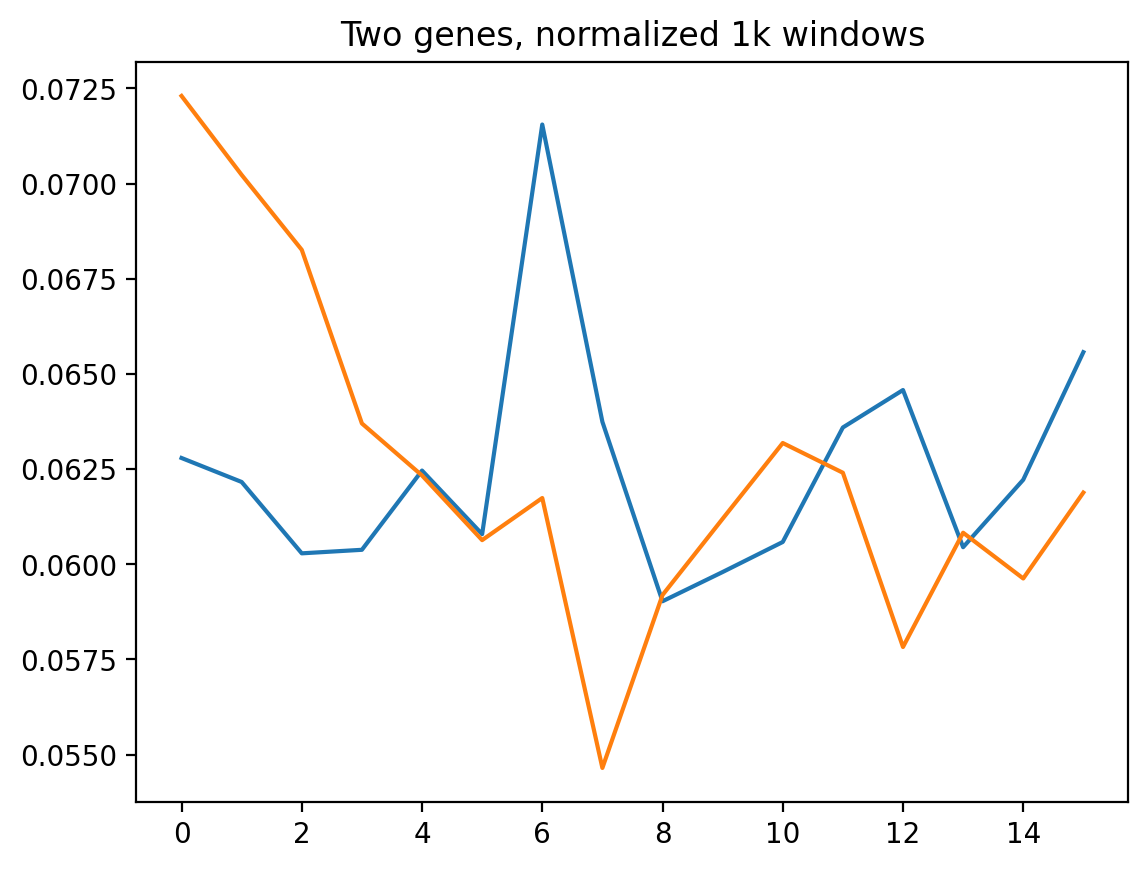

In [25]:
# Goal: Determine if the copy number correction algorithm is working as intended.
# Motivation: It appears that the gene chromatin 1k counts do not converge to an equal 
# value equivalent to 1 or 2 copies for the entire genome like we would expect when all genes
# are in G2/M or G1.
#
# Idea: Take two genes, perform copy correction and plot their curves. 
# This should give us some ideas.

chrom_dat = corrector1.chromatin_g_data[[10, 2000]]
gene1 = chrom_dat[0].sum(axis=1).sum(axis=1)
gene2 = chrom_dat[1].sum(axis=1).sum(axis=1)

gene1 = gene1 / gene1.sum()
gene2 = gene2 / gene2.sum()

# What if we assumed each gene had equal number of reads

plt.plot(gene1)
plt.plot(gene2)

# Aside, the size of the genomic window may be playing a role....

# Observations: Taking two genes at random, the timepoints for recovery should
# be omitted, but there is a clear difference between many of the genes that will not 
# equalize their occupancy values even with correction. So the idea of expanding the window
# to 5-10k may be a logical step forward...

# We have the 10k windows, we can try to copy correct those to see if we get profiles that
# match expectation...
plt.title("Two genes, normalized 1k windows")

In [27]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves(chroms=[10])

10, 00:00:09.065


In [28]:
mnase_analysis_rep1.normalize_and_compute_raw_replication_timing()

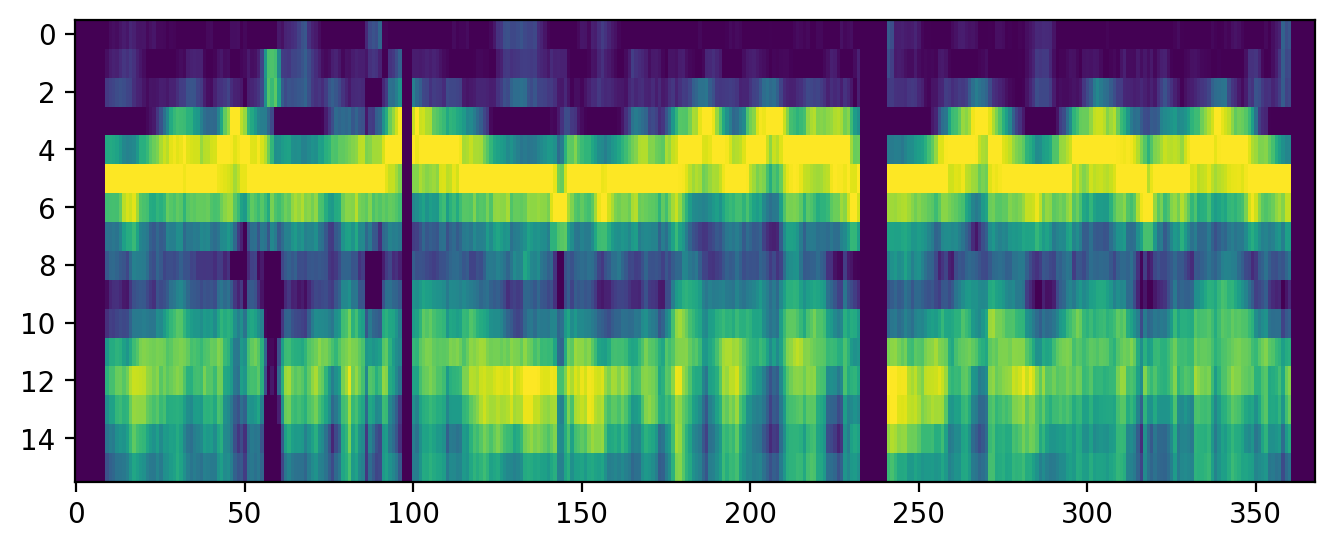

In [36]:
chr_data_10k = mnase_analysis_rep1.normalized_bin_curves.T

plt.figure(figsize=(8, 3))
plt.imshow(chr_data_10k, aspect='auto', vmin=0, vmax=1)

In [53]:
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')
H, Hpos = config1.calcH_function(config1.intervals_wt1, config1.WT1_TIMEPOINTS)


array([[3.10923989e-02, 3.10195421e-02, 3.08575790e-02, ...,
        1.46486789e-11, 1.03413784e-11, 2.24500000e-01],
       [1.28510412e-02, 1.34114426e-02, 1.39564861e-02, ...,
        2.99822452e-09, 2.23198595e-09, 2.24499999e-01],
       [3.46334916e-03, 3.76511238e-03, 4.08200849e-03, ...,
        4.38527571e-07, 3.46305690e-07, 2.24499657e-01],
       ...,
       [4.89338522e-11, 5.71084252e-11, 6.65805603e-11, ...,
        6.36232530e-03, 6.26067324e-03, 9.04392018e-02],
       [2.08456088e-11, 2.41910837e-11, 2.80467656e-11, ...,
        6.52462888e-03, 6.49140317e-03, 7.96012550e-02],
       [9.86262977e-12, 1.13818228e-11, 1.31233199e-11, ...,
        5.74025158e-03, 5.75294008e-03, 7.09119539e-02]])

In [61]:
replication_profile = pd.read_csv('output/replication_profiles/chrom_replication_timing_shared.csv').set_index(['chr', 'start'])
repl_profile_chr10 = replication_profile.loc[10]

replication_index    119
Name: 300000, dtype: int64

In [72]:
repl_profile_chr10.sort_values('replication_index')

,replication_index
start,
682000,105
192000,105
194000,105
196000,106
680000,106
...,...
268000,124
266000,124
264000,124


In [91]:
from src.CopyNumberCorrection import copy_number_correct_H_index

colors = ['red', 'blue']
idxs = [192000, 262000]
chr10_data = chr_data_10k.T.loc[10]
chr10_corrected = chr10_data.copy()

for idx in chr10_corrected.index:
    repl_idx = repl_profile_chr10.loc[idx].replication_index
    curve = chr10_data.loc[idx]
    corrected = copy_number_correct_H_index(H, curve, repl_idx)
    chr10_corrected.loc[idx] = corrected


Text(0.5, 0.98, 'Copy correction of 10k windows')

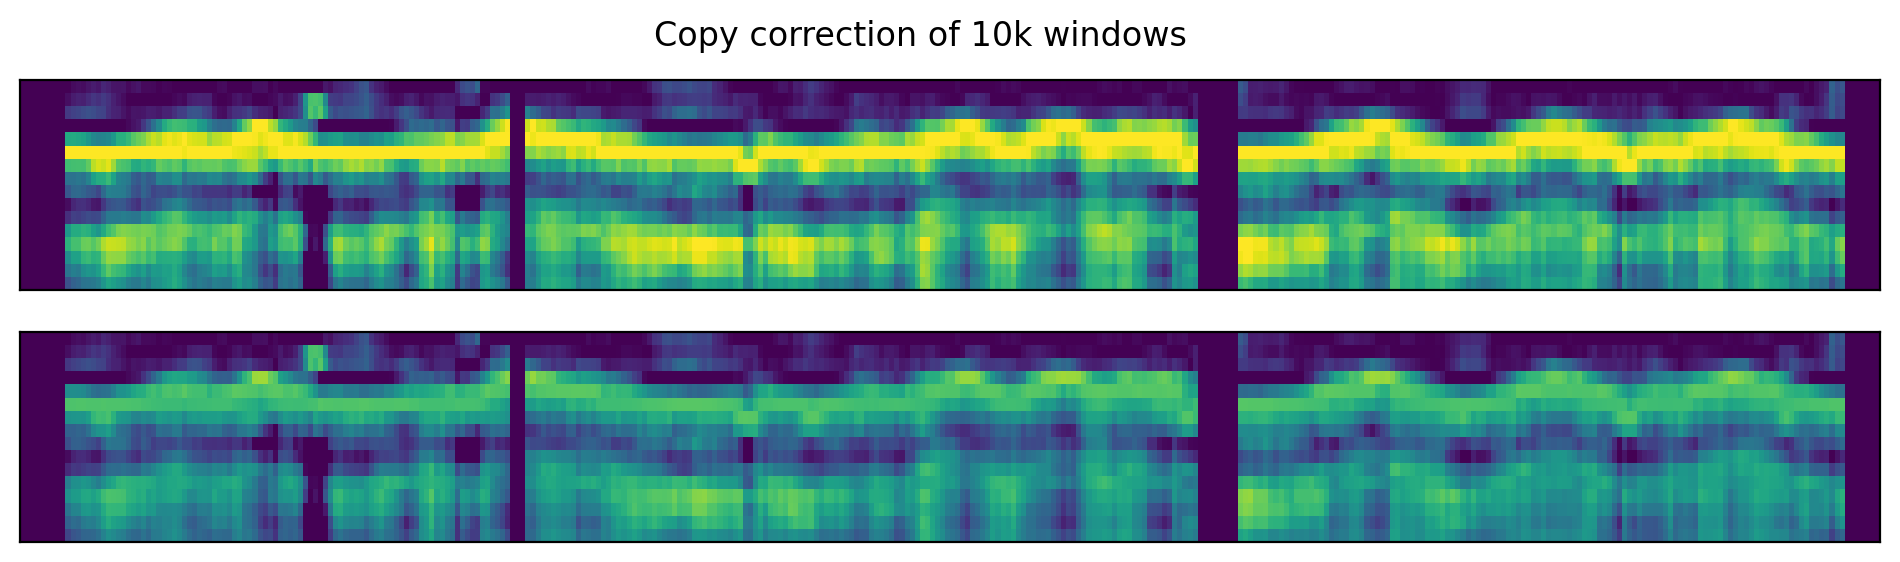

In [111]:
plt.figure(figsize=(12, 3))
plt.subplot(2, 1, 1)
plt.imshow(chr10_data.T, aspect='auto', vmin=0, vmax=1)
plt.xticks([])
plt.yticks([])

plt.subplot(2, 1, 2)
plt.imshow(chr10_corrected.T, aspect='auto', vmin=0, vmax=1)
plt.xticks([])
plt.yticks([])
plt.suptitle("Copy correction of 10k windows")

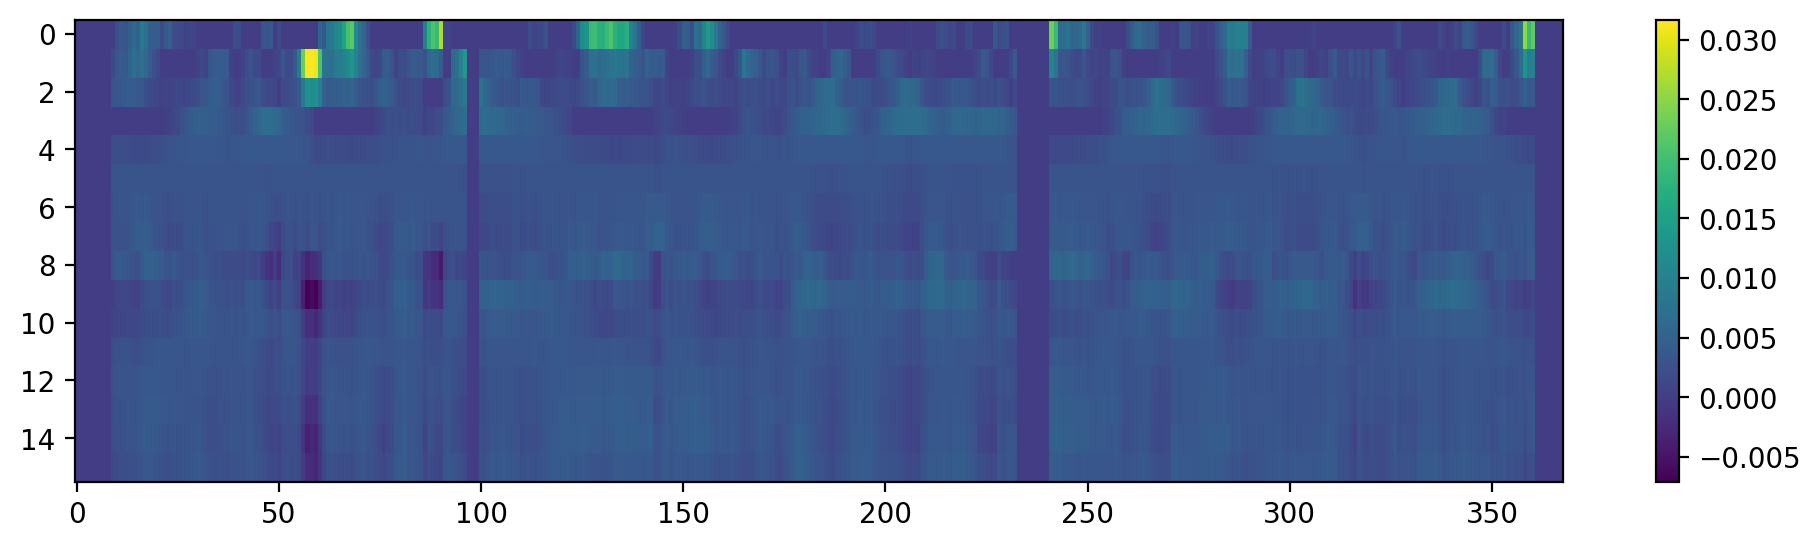

In [124]:
plt.figure(figsize=(12, 3))

total = chr10_data.sum(axis=0)
normalized_chr10_data = chr10_data / total.values.reshape((1, -1))
plt.imshow(normalized_chr10_data.T, aspect='auto')
plt.colorbar()

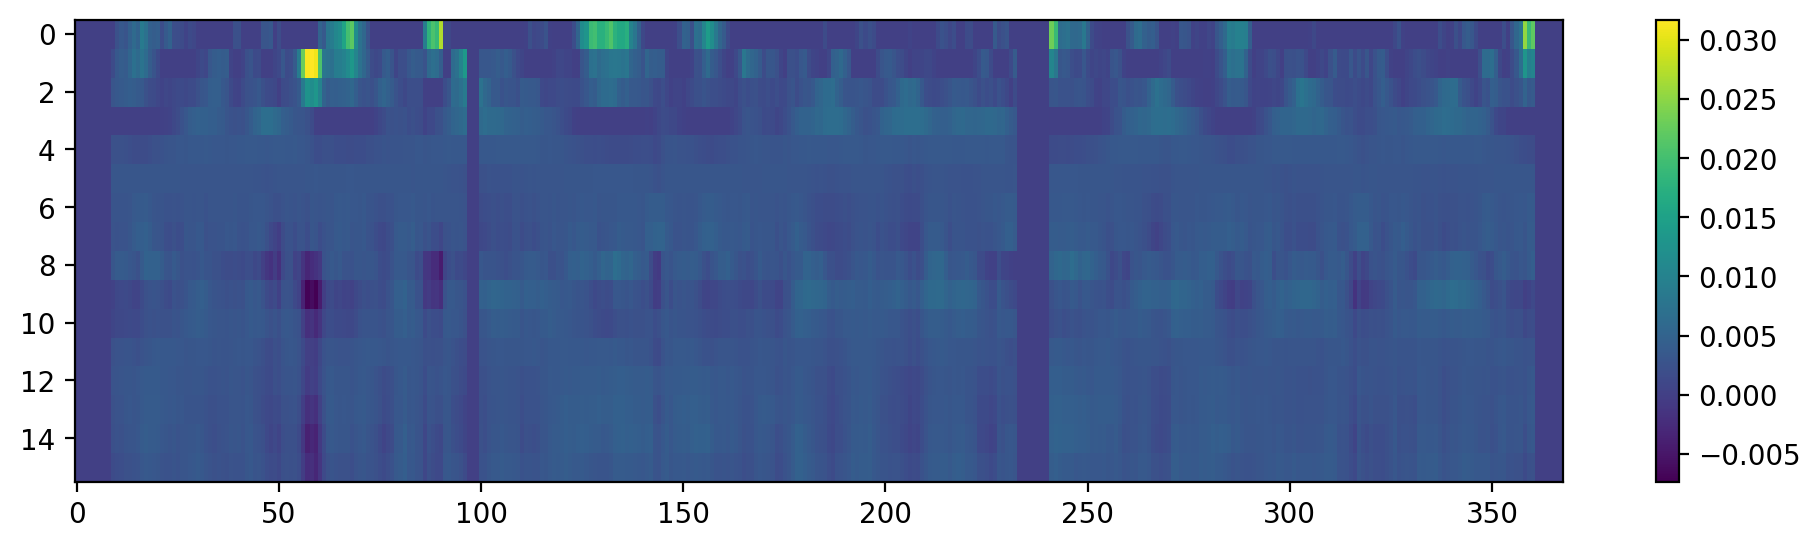

In [122]:
plt.figure(figsize=(12, 3))

total = chr10_corrected.sum(axis=0)
normalized_chr10_corrected = chr10_corrected / total.values.reshape((1, -1))
plt.imshow(normalized_chr10_corrected.T, aspect='auto')
plt.colorbar()

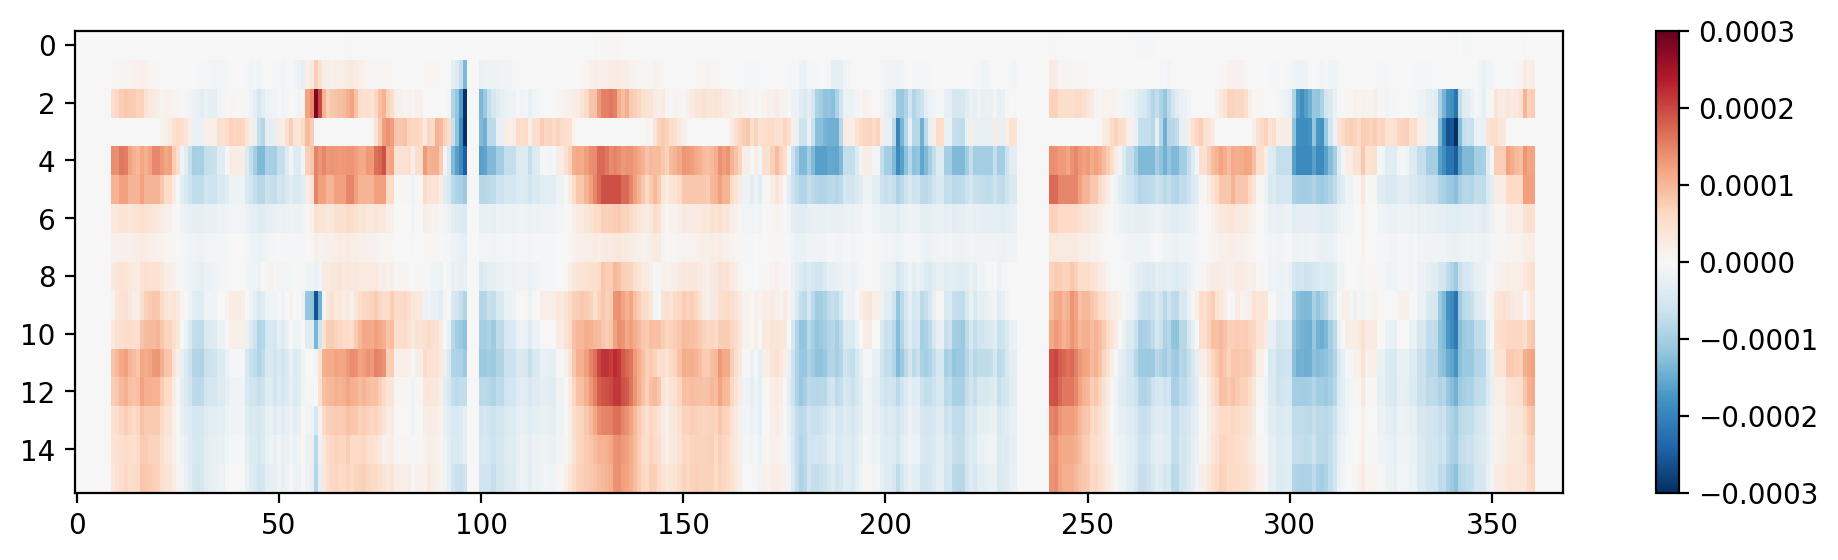

In [127]:
plt.figure(figsize=(12, 3))
plt.imshow(normalized_chr10_corrected.T - normalized_chr10_data.T, aspect='auto', 
           vmin=-0.0003, vmax=0.0003, cmap='RdBu_r')
plt.colorbar()
